## Imports

In [1]:
from pprint import pprint
import json
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedKFold
from collections import Counter
from joblib import Parallel, delayed
from tqdm import tqdm 
import shap
import shapiq
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_curve,
    roc_auc_score,
    auc,
    precision_recall_curve,
    precision_score,
    recall_score,
    average_precision_score,
    f1_score,
    brier_score_loss, 
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Constants

In [2]:
RANDOM_SEED = 0
TEST_SIZE_SPLIT = 0.1

## Functions

In [3]:
# from sklearn.metrics import (
#     accuracy_score,
#     roc_auc_score,
#     average_precision_score,
#     f1_score,
#     classification_report,
#     confusion_matrix,
#     ConfusionMatrixDisplay
# )
# import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, labels_list=None, cm_normalize=None):
    """
    Evaluate a binary classification model with multiple metrics and plots.

    Args:
        model: Fitted scikit-learn model with predict() and predict_proba().
        X_test (array-like): Test feature matrix.
        y_test (array-like): True labels for the test set.
        labels_list (LabelEncoder, optional): If provided, class names are them; 
            otherwise defaults to ["Class 0", "Class 1, ..."].
        cm_normalize (str or None): Normalization method for confusion matrix.
            Options: None, 'true', 'pred', 'all'.
            Default: None (no normalization).

    Prints:
        - Accuracy, Balanced Accuracy
        - ROC AUC (single value)
        - PR AUC (class 0, class 1, macro, micro, weighted)
        - F1 Score (binary, macro, micro, weighted, per class)
        - Precision (macro, micro, weighted, per class)
        - Recall (macro, micro, weighted, per class)
        - Brier Score Loss
        - Log Loss
        - Classification report

    Displays:
        - Confusion matrix (normalized by predicted labels).
    """

    sns.reset_defaults()
    
    if labels_list is None:
        labels = ["Class " + str(i) for i in range(len(set(y_test)))]
    else:
        labels = labels_list

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    # --- Base metrics ---
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # --- ROC AUC (single value) ---
    roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

    # --- PR AUC variations ---
    pr_auc_class1 = average_precision_score(y_test, y_pred_proba[:, 1])
    pr_auc_class0 = average_precision_score(1 - y_test, y_pred_proba[:, 0])
    pr_auc_macro = np.mean([pr_auc_class0, pr_auc_class1])
    pr_auc_micro = average_precision_score(y_test, y_pred_proba[:, 1], average="micro")
    pr_auc_weighted = (
        pr_auc_class0 * np.mean(y_test == 0) +
        pr_auc_class1 * np.mean(y_test == 1)
    )

    # --- F1 scores ---
    f1_binary = f1_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_micro = f1_score(y_test, y_pred, average="micro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    f1_per_class = f1_score(y_test, y_pred, average=None)

    # --- Precision ---
    precision_macro = precision_score(y_test, y_pred, average="macro")
    precision_micro = precision_score(y_test, y_pred, average="micro")
    precision_weighted = precision_score(y_test, y_pred, average="weighted")
    precision_per_class = precision_score(y_test, y_pred, average=None)

    # --- Recall ---
    recall_macro = recall_score(y_test, y_pred, average="macro")
    recall_micro = recall_score(y_test, y_pred, average="micro")
    recall_weighted = recall_score(y_test, y_pred, average="weighted")
    recall_per_class = recall_score(y_test, y_pred, average=None)

    # --- Calibration & loss metrics ---
    brier = brier_score_loss(y_test, y_pred_proba[:, 1])
    logloss = log_loss(y_test, y_pred_proba)

    # --- Print metrics ---
    print("===== Evaluation Metrics =====")
    print(f"Accuracy:              {accuracy:.4f}")
    print(f"Balanced Accuracy:     {balanced_acc:.4f}")
    print(f"ROC AUC:               {roc_auc:.4f}")
    print("\n--- PR AUC ---")
    print(f"PR AUC (micro):        {pr_auc_micro:.4f}")
    print(f"PR AUC (macro):        {pr_auc_macro:.4f}")
    print(f"PR AUC (weighted):     {pr_auc_weighted:.4f}")
    print(f"PR AUC (class 0):      {pr_auc_class0:.4f}")
    print(f"PR AUC (class 1):      {pr_auc_class1:.4f}")
    print("\n--- F1-Scores ---")
    print(f"F1-Score (micro):            {f1_micro:.4f}")
    print(f"F1-Score (macro):            {f1_macro:.4f}")
    print(f"F1-Score (weighted):         {f1_weighted:.4f}")
    print(f"F1-Score (class 0):          {f1_per_class[0]:.4f}")
    print(f"F1-Score (class 1):          {f1_per_class[1]:.4f}")
    print("\n--- Precision ---")
    print(f"Precision (micro):     {precision_micro:.4f}")
    print(f"Precision (macro):     {precision_macro:.4f}")
    print(f"Precision (weighted):  {precision_weighted:.4f}")
    print(f"Precision (class 0):   {precision_per_class[0]:.4f}")
    print(f"Precision (class 1):   {precision_per_class[1]:.4f}")
    print("\n--- Recall ---")
    print(f"Recall (micro):        {recall_micro:.4f}")
    print(f"Recall (macro):        {recall_macro:.4f}")
    print(f"Recall (weighted):     {recall_weighted:.4f}")
    print(f"Recall (class 0):      {recall_per_class[0]:.4f}")
    print(f"Recall (class 1):      {recall_per_class[1]:.4f}")
    print("\n--- Loss Metrics ---")
    print(f"Brier Score Loss:      {brier:.4f}")
    print(f"Log Loss:              {logloss:.4f}\n")

    # --- Classification report ---
    print("===== Classification Report =====")
    print(classification_report(y_test, y_pred, target_names=labels))

    # --- Confusion Matrix ---
    fig, ax = plt.subplots(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred, normalize=cm_normalize)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)

    im = ax.images[0]
    im.set_clim(0, 1 if cm_normalize else cm.max())
    fig.colorbar(im, ax=ax)

    plt.title(f"Confusion Matrix")
    plt.xticks(rotation=45)
    plt.show()


## Configurations

In [4]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'mathtext.fontset': 'cm'
})

## Machine Learning Models

### Loading Indices

In [5]:
# train_indices = np.load("../data/support/train_indices.npy")
# test_indices = np.load("../data/support/test_indices.npy")

df = pd.read_pickle("../data/processed/GFA_binary_processed.pkl.zip", compression='zip')
df = df.drop('sample_id', axis=1)

TARGET = ['target']
FEATURES = df.columns.drop(TARGET)

le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])

indices = df.index
train_indices, test_indices = train_test_split(
    indices, test_size=TEST_SIZE_SPLIT, random_state=RANDOM_SEED, stratify=df[TARGET]
)

/tmp/ipykernel_245259/2660050064.py:5: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop('sample_id', axis=1)
/tmp/ipykernel_245259/2660050064.py:8: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  FEATURES = df.columns.drop(TARGET)
/home/diogo-carvalho/miniconda3/envs/GFA/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## CHEM

In [6]:
df_chem = pd.read_pickle("../data/processed/GFA_binary_CHEM.pkl.zip", compression='zip')
df_chem

,Ag,Al,As,B,Ba,Be,Bi,Br,Ca,Cd,...,Tl,Tm,V,W,Y,Yb,Zn,Zr,Kod,GF
0,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.436445,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,26356,Crystal
1,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.400600,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,26356,Crystal
2,0.000000,0.0,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,27653,Crystal
3,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.378500,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,26356,Crystal
4,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.341500,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,26356,Crystal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51617,0.546000,0.0,0.1550,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,27768,Crystal
51618,0.574587,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.037994,0.0,0.0,0.0,0.0,0.0,36491,Crystal
51619,0.598000,0.0,0.1490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,27768,Crystal
51620,0.602000,0.0,0.0020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,27768,Crystal


In [7]:
df_chem = pd.read_pickle("../data/processed/GFA_binary_CHEM.pkl.zip", compression='zip')
df_chem = df_chem.drop('Kod', axis=1)
display(df_chem)
print(df_chem.columns)
print(Counter(df_chem['GF']))

TARGET_name = 'GF'
TARGET = [TARGET_name]
FEATURES = df_chem.columns.drop(TARGET)

le = LabelEncoder()
df_chem[TARGET_name] = le.fit_transform(df_chem[TARGET_name])

,Ag,Al,As,B,Ba,Be,Bi,Br,Ca,Cd,...,Ti,Tl,Tm,V,W,Y,Yb,Zn,Zr,GF
0,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.436445,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,Crystal
1,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.400600,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,Crystal
2,0.000000,0.0,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,Crystal
3,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.378500,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,Crystal
4,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.341500,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,Crystal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51617,0.546000,0.0,0.1550,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,Crystal
51618,0.574587,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.037994,0.0,0.0,0.0,0.0,0.0,Crystal
51619,0.598000,0.0,0.1490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,Crystal
51620,0.602000,0.0,0.0020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,Crystal


Index(['Ag', 'Al', 'As', 'B', 'Ba', 'Be', 'Bi', 'Br', 'Ca', 'Cd', 'Ce', 'Cl',
       'Co', 'Cr', 'Cs', 'Cu', 'Dy', 'Er', 'Eu', 'F', 'Fe', 'Ga', 'Gd', 'Ge',
       'H', 'Hf', 'Hg', 'Ho', 'I', 'In', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn',
       'Mo', 'N', 'Na', 'Nb', 'Nd', 'Ni', 'O', 'P', 'Pb', 'Pr', 'Rb', 'S',
       'Sb', 'Sc', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Te', 'Ti', 'Tl',
       'Tm', 'V', 'W', 'Y', 'Yb', 'Zn', 'Zr', 'GF'],
      dtype='object')
Counter({'Glass': 36033, 'Crystal': 14864})


In [8]:
train_df_chem = df_chem.loc[train_indices]
test_df_chem = df_chem.loc[test_indices]

X_train_chem = train_df_chem.reindex(FEATURES, axis=1).values
y_train_chem = train_df_chem.reindex(TARGET, axis=1).values.ravel()

X_test_chem = test_df_chem.reindex(FEATURES, axis=1).values
y_test_chem = test_df_chem.reindex(TARGET, axis=1).values.ravel()

X_chem = df_chem.reindex(FEATURES, axis=1).values
y_chem = df_chem.reindex(TARGET, axis=1).values.ravel()

optimized_model_path = '../src/hyperparameters_tunning/GFA_binary_CHEM/model/best_model_binary_unimodal_RF_f1_score_macro_2000_TPESampler.pkl'
optimized_model = joblib.load(optimized_model_path)
all_hyperparams = optimized_model.get_params()

print(f"\nFound {len(all_hyperparams)} optimized hyperparameters.")
print("Listing all parameters:")
pprint(all_hyperparams)

# with open('../data/support/optimized_hyperparams_CHEM.json', 'w') as f:
#     json.dump(all_hyperparams, f, indent=2, default=str)


Found 19 optimized hyperparameters.
Listing all parameters:
{'bootstrap': True,
 'ccp_alpha': 4.429172017000593e-05,
 'class_weight': 'balanced_subsample',
 'criterion': 'gini',
 'max_depth': 90,
 'max_features': None,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0,
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 722,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}


===== Evaluation Metrics =====
Accuracy:              0.8259
Balanced Accuracy:     0.7786
ROC AUC:               0.8888

--- PR AUC ---
PR AUC (micro):        0.9492
PR AUC (macro):        0.8652
PR AUC (weighted):     0.9001
PR AUC (class 0):      0.7811
PR AUC (class 1):      0.9492

--- F1-Scores ---
F1-Score (micro):            0.8259
F1-Score (macro):            0.7847
F1-Score (weighted):         0.8239
F1-Score (class 0):          0.6904
F1-Score (class 1):          0.8789

--- Precision ---
Precision (micro):     0.8259
Precision (macro):     0.7920
Precision (weighted):  0.8227
Precision (class 0):   0.7180
Precision (class 1):   0.8659

--- Recall ---
Recall (micro):        0.8259
Recall (macro):        0.7786
Recall (weighted):     0.8259
Recall (class 0):      0.6649
Recall (class 1):      0.8923

--- Loss Metrics ---
Brier Score Loss:      0.1192
Log Loss:              0.3733

===== Classification Report =====
              precision    recall  f1-score   support

     Cr

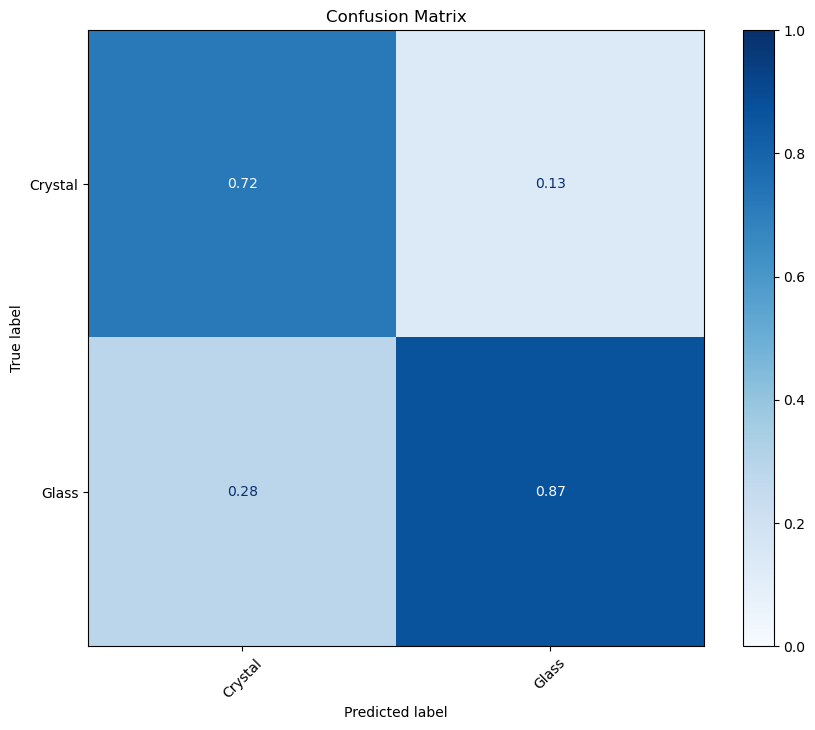

In [9]:
#RF = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)
RF = RandomForestClassifier(**all_hyperparams)

RF.fit(X_train_chem, y_train_chem)

y_pred_chem = RF.predict(X_test_chem)
y_pred_proba_chem = RF.predict_proba(X_test_chem)

classes_label_binary = ["Crystal", "Glass"]

evaluate_model(RF, X_test_chem, y_test_chem, labels_list=le.classes_, cm_normalize="pred")

In [10]:
# import numpy as np
# import shap
# from joblib import Parallel, delayed
# from tqdm import tqdm 

# n_jobs = 14 
# feat_names = df_chem[FEATURES].columns.to_list()
# explainer = shap.Explainer(RF, feature_names=feat_names, output_names=classes_label_binary, seed=RANDOM_SEED)

# # Split X_train into chunks (if one chunk finishes early, the core immediately picks up the next one).
# n_chunks = n_jobs * 20
# chunks = np.array_split(X_train_chem, n_chunks) 

# print(f"Splitting data into {n_chunks} chunks to run on {n_jobs} cores...")

# # Helper function
# def get_explanation(chunk):
#     # check_additivity=False prevents common numerical precision errors 
#     # that can occur when parallelizing Random Forest calculations
#     return explainer(chunk, check_additivity=False) 

# # Run in parallel with TQDM
# print("Calculating SHAP values...")

# explanations_list = Parallel(n_jobs=n_jobs)(
#     delayed(get_explanation)(chunk) for chunk in tqdm(chunks, desc="Progress")
# )

# # Concatenate results
# print("Concatenating results...")
# shap_values_all = np.concatenate([e.values for e in explanations_list], axis=0)
# base_values_all = np.concatenate([e.base_values for e in explanations_list], axis=0)
# data_all = np.concatenate([e.data for e in explanations_list], axis=0)

# # Reconstruct the final Explanation object
# explanation = shap.Explanation(
#     values=shap_values_all,
#     base_values=base_values_all,
#     data=data_all,
#     feature_names=feat_names,
#     output_names=classes_label_binary
# )

# print("Done! Shape:", explanation.values.shape)

# # Save the explanation object to a file
# joblib.dump(explanation, '../data/support/explanation_shap/explanation_shap_CHEM.joblib')
# print("Explanation object saved successfully!")

### FEATENG

In [11]:
df_feateng = pd.read_pickle("../data/processed/GFA_binary_FEATENG.pkl.zip", compression='zip')
df_feateng = df_feateng.drop('Kod', axis=1)
display(df_feateng)
print(df_feateng.columns)
print(Counter(df_feateng['GF']))

TARGET_name = 'GF'
TARGET = [TARGET_name]
FEATURES = df_feateng.columns.drop(TARGET)

le = LabelEncoder()
df_feateng[TARGET_name] = le.fit_transform(df_feateng[TARGET_name])

,A|vdw_radius_uff|std,W|atomic_radius_rahm|mean,W|NpValence|mean,A|pettifor_number|sum,W|FusionEnthalpy|sum,W|num_oxistates|mean,A|FusionEnthalpy|mean,W|NdValence|mean,W|NsValence|sum,A|GSbandgap|std,...,W|GSbandgap|sum,A|num_oxistates|std,W|NdUnfilled|max,W|NpUnfilled|sum,A|melting_point|std,A|NUnfilled|sum,A|num_oxistates|max,W|covalent_radius_cordero|std,A|en_Martynov_Batsanov|std,GF
0,6.150000,121.000000,1.345332,170.0,11.602337,1.281777,10.761000,5.000000,2.000000,0.232000,...,0.261489,0.500000,0.000000,3.309336,73.050000,7.0,3.0,7.242986,0.871001,Crystal
1,6.150000,121.000000,1.399100,170.0,12.076857,1.299700,10.761000,5.000000,2.000000,0.232000,...,0.278122,0.500000,0.000000,3.201800,73.050000,7.0,3.0,12.315100,0.871001,Crystal
2,12.000000,120.999450,1.999950,181.0,17.380706,1.500000,20.910000,5.000000,2.000000,0.232000,...,0.463954,0.000000,0.000000,2.000100,183.650000,5.0,3.0,68.987150,0.126307,Crystal
3,7.337726,80.618667,0.945233,255.0,12.842169,0.873833,23.910667,3.285333,2.000000,0.317684,...,0.292826,0.471405,0.000000,3.164300,490.763833,11.0,3.0,34.039245,0.713755,Crystal
4,7.337726,80.619000,0.982300,255.0,13.328692,0.886167,23.910667,3.285667,2.000000,0.317684,...,0.309963,0.471405,0.000000,3.053100,490.763833,11.0,3.0,35.701994,0.713755,Crystal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51617,47.087602,74.213667,0.553667,254.0,10.472579,0.917667,12.487000,2.336667,1.454000,1.038033,...,0.658398,0.816497,0.000000,1.063000,370.831022,6.0,4.0,26.114446,1.239777,Crystal
51618,55.437442,51.448458,0.389988,323.0,7.472438,0.429851,10.195000,1.490657,1.425413,0.459859,...,0.010914,1.299038,0.265961,0.764559,816.047954,11.0,4.0,32.652561,2.132943,Crystal
51619,47.087602,74.370333,0.486333,254.0,10.834373,0.885000,12.487000,2.490000,1.402000,1.038033,...,0.557106,0.816497,0.000000,0.953000,370.831022,6.0,4.0,30.647753,1.239777,Crystal
51620,47.087602,73.552000,0.530000,254.0,7.532996,0.931333,12.487000,2.013333,1.398000,1.038033,...,0.871992,0.816497,0.000000,0.798000,370.831022,6.0,4.0,35.553740,1.239777,Crystal


Index(['A|vdw_radius_uff|std', 'W|atomic_radius_rahm|mean', 'W|NpValence|mean',
       'A|pettifor_number|sum', 'W|FusionEnthalpy|sum', 'W|num_oxistates|mean',
       'A|FusionEnthalpy|mean', 'W|NdValence|mean', 'W|NsValence|sum',
       'A|GSbandgap|std', 'W|GSvolume_pa|mean', 'W|GSbandgap|sum',
       'A|num_oxistates|std', 'W|NdUnfilled|max', 'W|NpUnfilled|sum',
       'A|melting_point|std', 'A|NUnfilled|sum', 'A|num_oxistates|max',
       'W|covalent_radius_cordero|std', 'A|en_Martynov_Batsanov|std', 'GF'],
      dtype='object')
Counter({'Glass': 36033, 'Crystal': 14864})


In [12]:
train_df_feateng = df_feateng.loc[train_indices]
test_df_feateng = df_feateng.loc[test_indices]

X_train_feateng = train_df_feateng.reindex(FEATURES, axis=1).values
y_train_feateng = train_df_feateng.reindex(TARGET, axis=1).values.ravel()

X_test_feateng = test_df_feateng.reindex(FEATURES, axis=1).values
y_test_feateng = test_df_feateng.reindex(TARGET, axis=1).values.ravel()

X_feateng = df_feateng.reindex(FEATURES, axis=1).values
y_feateng = df_feateng.reindex(TARGET, axis=1).values.ravel()

optimized_model_path = '../src/hyperparameters_tunning/GFA_binary_FEATENG/model/best_model_binary_unimodal_RF_f1_score_macro_2000_TPESampler.pkl'
optimized_model = joblib.load(optimized_model_path)
all_hyperparams = optimized_model.get_params()

print(f"\nFound {len(all_hyperparams)} optimized hyperparameters.")
print("Listing all parameters:")
pprint(all_hyperparams)

# with open('../data/support/optimized_hyperparams_FEATENG.json', 'w') as f:
#     json.dump(all_hyperparams, f, indent=2, default=str)


Found 19 optimized hyperparameters.
Listing all parameters:
{'bootstrap': True,
 'ccp_alpha': 0,
 'class_weight': 'balanced',
 'criterion': 'log_loss',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0,
 'min_samples_leaf': 2,
 'min_samples_split': 7,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 719,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}


===== Evaluation Metrics =====
Accuracy:              0.8236
Balanced Accuracy:     0.7661
ROC AUC:               0.8892

--- PR AUC ---
PR AUC (micro):        0.9496
PR AUC (macro):        0.8662
PR AUC (weighted):     0.9009
PR AUC (class 0):      0.7828
PR AUC (class 1):      0.9496

--- F1-Scores ---
F1-Score (micro):            0.8236
F1-Score (macro):            0.7770
F1-Score (weighted):         0.8194
F1-Score (class 0):          0.6751
F1-Score (class 1):          0.8789

--- Precision ---
Precision (micro):     0.8236
Precision (macro):     0.7925
Precision (weighted):  0.8185
Precision (class 0):   0.7300
Precision (class 1):   0.8549

--- Recall ---
Recall (micro):        0.8236
Recall (macro):        0.7661
Recall (weighted):     0.8236
Recall (class 0):      0.6279
Recall (class 1):      0.9043

--- Loss Metrics ---
Brier Score Loss:      0.1204
Log Loss:              0.3772

===== Classification Report =====
              precision    recall  f1-score   support

     Cr

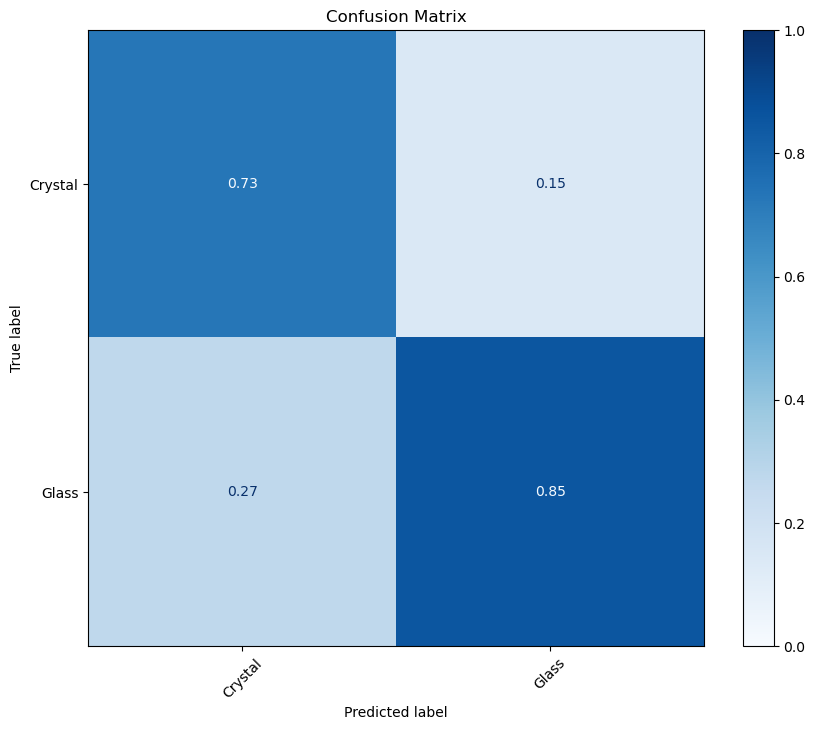

In [13]:
#RF = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)
RF = RandomForestClassifier(**all_hyperparams)

RF.fit(X_train_feateng, y_train_feateng)

y_pred_feateng = RF.predict(X_test_feateng)
y_pred_proba_feateng = RF.predict_proba(X_test_feateng)

classes_label_binary = ["Crystal", "Glass"]

evaluate_model(RF, X_test_feateng, y_test_feateng, labels_list=le.classes_, cm_normalize="pred")

In [14]:
# import numpy as np
# import shap
# from joblib import Parallel, delayed
# from tqdm import tqdm 

# n_jobs = 14 
# feat_names = df_feateng[FEATURES].columns.to_list()
# explainer = shap.Explainer(RF, feature_names=feat_names, output_names=classes_label_binary, seed=RANDOM_SEED)

# # Split X_train into chunks (if one chunk finishes early, the core immediately picks up the next one).
# n_chunks = n_jobs * 20
# chunks = np.array_split(X_train_feateng, n_chunks) 

# print(f"Splitting data into {n_chunks} chunks to run on {n_jobs} cores...")

# # Helper function
# def get_explanation(chunk):
#     # check_additivity=False prevents common numerical precision errors 
#     # that can occur when parallelizing Random Forest calculations
#     return explainer(chunk, check_additivity=False) 

# # Run in parallel with TQDM
# print("Calculating SHAP values...")

# explanations_list = Parallel(n_jobs=n_jobs)(
#     delayed(get_explanation)(chunk) for chunk in tqdm(chunks, desc="Progress")
# )

# # Concatenate results
# print("Concatenating results...")
# shap_values_all = np.concatenate([e.values for e in explanations_list], axis=0)
# base_values_all = np.concatenate([e.base_values for e in explanations_list], axis=0)
# data_all = np.concatenate([e.data for e in explanations_list], axis=0)

# # Reconstruct the final Explanation object
# explanation = shap.Explanation(
#     values=shap_values_all,
#     base_values=base_values_all,
#     data=data_all,
#     feature_names=feat_names,
#     output_names=classes_label_binary
# )

# print("Done! Shape:", explanation.values.shape)

# # Save the explanation object to a file
# joblib.dump(explanation, '../data/support/explanation_shap/explanation_shap_FEATENG.joblib')
# print("Explanation object saved successfully!")

### GS

In [15]:
df_gs = pd.read_pickle("../data/processed/GFA_binary_GS.pkl.zip", compression='zip')
df_gs = df_gs.drop('Kod', axis=1)
display(df_gs)
print(df_gs.columns)
print(Counter(df_gs['GF']))

TARGET_name = 'GF'
TARGET = [TARGET_name]
FEATURES = df_gs.columns.drop(TARGET)

le = LabelEncoder()
df_gs[TARGET_name] = le.fit_transform(df_gs[TARGET_name])

,Kw_Tx,Kw_Tc,Kh_Tc,H_Tx,gamma_Tc,jezica,GF
0,0.053885,0.277478,1.114669,0.113780,0.509686,1.337523e-05,Crystal
1,0.047302,0.299266,1.382360,0.097682,0.527885,1.830555e-05,Crystal
2,0.042967,0.104088,0.249421,0.089777,0.394079,1.643469e-05,Crystal
3,0.161115,0.139911,0.541528,0.267755,0.463024,3.667121e-03,Crystal
4,0.166038,0.153593,0.644383,0.273067,0.473644,4.272514e-03,Crystal
...,...,...,...,...,...,...,...
51617,0.032749,0.143965,0.479901,0.058896,0.449865,5.968762e-06,Crystal
51618,0.031069,0.024906,0.043386,0.077475,0.304013,1.085713e-06,Crystal
51619,0.014055,0.105325,0.278355,0.027223,0.409959,2.689819e-06,Crystal
51620,0.052798,0.081111,0.161702,0.126528,0.351654,1.325419e-06,Crystal


Index(['Kw_Tx', 'Kw_Tc', 'Kh_Tc', 'H_Tx', 'gamma_Tc', 'jezica', 'GF'], dtype='object')
Counter({'Glass': 36033, 'Crystal': 14864})


In [16]:
train_df_gs = df_gs.loc[train_indices]
test_df_gs = df_gs.loc[test_indices]

X_train_gs = train_df_gs.reindex(FEATURES, axis=1).values
y_train_gs = train_df_gs.reindex(TARGET, axis=1).values.ravel()

X_test_gs = test_df_gs.reindex(FEATURES, axis=1).values
y_test_gs = test_df_gs.reindex(TARGET, axis=1).values.ravel()

X_gs = df_gs.reindex(FEATURES, axis=1).values
y_gs = df_gs.reindex(TARGET, axis=1).values.ravel()

optimized_model_path = '../src/hyperparameters_tunning/GFA_binary_GS/model/best_model_binary_unimodal_RF_f1_score_macro_2000_TPESampler.pkl'
optimized_model = joblib.load(optimized_model_path)
all_hyperparams = optimized_model.get_params()

print(f"\nFound {len(all_hyperparams)} optimized hyperparameters.")
print("Listing all parameters:")
pprint(all_hyperparams)

# with open('../data/support/optimized_hyperparams_GS.json', 'w') as f:
#     json.dump(all_hyperparams, f, indent=2, default=str)



Found 19 optimized hyperparameters.
Listing all parameters:
{'bootstrap': True,
 'ccp_alpha': 1.820668428779548e-05,
 'class_weight': 'balanced_subsample',
 'criterion': 'log_loss',
 'max_depth': 45,
 'max_features': 2.176012764241079e-05,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0,
 'min_samples_leaf': 6,
 'min_samples_split': 15,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 419,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}


In [17]:
missing_rows = test_df_gs[test_df_gs.isnull().any(axis=1)]
display(missing_rows)


,Kw_Tx,Kw_Tc,Kh_Tc,H_Tx,gamma_Tc,jezica,GF
22719,-0.105181,-0.123801,-1.356265,-0.101868,0.447090,NaN,1
22147,0.096369,0.107509,0.379495,0.158190,0.445381,NaN,1
22164,0.158836,0.207802,1.201009,0.256528,0.510740,NaN,1
9745,0.131876,0.031300,0.061785,0.285380,0.337463,NaN,0
22353,0.134856,0.138374,0.489337,0.232972,0.454269,NaN,1
22158,0.164871,0.219141,1.334683,0.267357,0.516995,NaN,1
50672,0.049158,0.026941,0.050010,0.113175,0.321602,NaN,1
9190,0.099021,0.200660,6.326211,0.128997,0.547788,NaN,1
911,0.098448,0.044032,0.084345,0.226880,0.333320,NaN,0
49363,0.090147,0.095308,0.246434,0.174048,0.404001,NaN,1


===== Evaluation Metrics =====
Accuracy:              0.7037
Balanced Accuracy:     0.6207
ROC AUC:               0.6949

--- PR AUC ---
PR AUC (micro):        0.8371
PR AUC (macro):        0.6727
PR AUC (weighted):     0.7411
PR AUC (class 0):      0.5083
PR AUC (class 1):      0.8371

--- F1-Scores ---
F1-Score (micro):            0.7037
F1-Score (macro):            0.6252
F1-Score (weighted):         0.6966
F1-Score (class 0):          0.4536
F1-Score (class 1):          0.7968

--- Precision ---
Precision (micro):     0.7037
Precision (macro):     0.6330
Precision (weighted):  0.6919
Precision (class 0):   0.4914
Precision (class 1):   0.7746

--- Recall ---
Recall (micro):        0.7037
Recall (macro):        0.6207
Recall (weighted):     0.7037
Recall (class 0):      0.4213
Recall (class 1):      0.8202

--- Loss Metrics ---
Brier Score Loss:      0.1963
Log Loss:              0.5766

===== Classification Report =====
              precision    recall  f1-score   support

     Cr

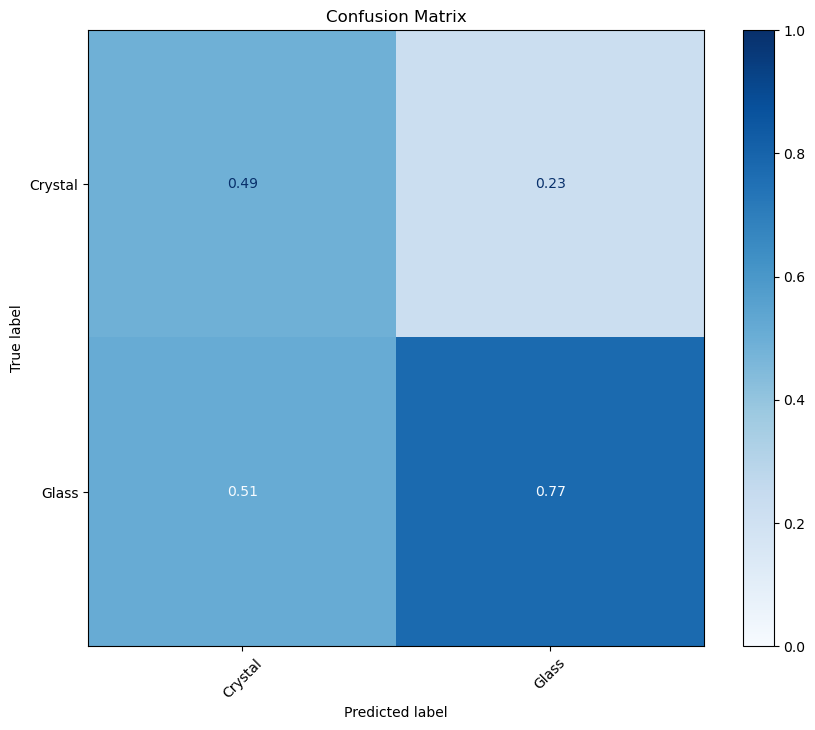

In [18]:
#RF = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)
RF = RandomForestClassifier(**all_hyperparams)

RF.fit(X_train_gs, y_train_gs)

y_pred_gs = RF.predict(X_test_gs)
y_pred_proba_gs = RF.predict_proba(X_test_gs)

classes_label_binary = ["Crystal", "Glass"]

evaluate_model(RF, X_test_gs, y_test_gs, labels_list=le.classes_, cm_normalize="pred")

In [19]:
# import numpy as np
# import shap
# from joblib import Parallel, delayed
# from tqdm import tqdm 

# n_jobs = 14 
# feat_names = df_gs[FEATURES].columns.to_list()
# explainer = shap.Explainer(RF, feature_names=feat_names, output_names=classes_label_binary, seed=RANDOM_SEED)

# # Split X_train into chunks (if one chunk finishes early, the core immediately picks up the next one).
# n_chunks = n_jobs * 20
# chunks = np.array_split(X_train_gs, n_chunks) 

# print(f"Splitting data into {n_chunks} chunks to run on {n_jobs} cores...")

# # Helper function
# def get_explanation(chunk):
#     # check_additivity=False prevents common numerical precision errors 
#     # that can occur when parallelizing Random Forest calculations
#     return explainer(chunk, check_additivity=False) 

# # Run in parallel with TQDM
# print("Calculating SHAP values...")

# explanations_list = Parallel(n_jobs=n_jobs)(
#     delayed(get_explanation)(chunk) for chunk in tqdm(chunks, desc="Progress")
# )

# # Concatenate results
# print("Concatenating results...")
# shap_values_all = np.concatenate([e.values for e in explanations_list], axis=0)
# base_values_all = np.concatenate([e.base_values for e in explanations_list], axis=0)
# data_all = np.concatenate([e.data for e in explanations_list], axis=0)

# # Reconstruct the final Explanation object
# explanation = shap.Explanation(
#     values=shap_values_all,
#     base_values=base_values_all,
#     data=data_all,
#     feature_names=feat_names,
#     output_names=classes_label_binary
# )

# print("Done! Shape:", explanation.values.shape)

# # Save the explanation object to a file
# joblib.dump(explanation, '../data/support/explanation_shap/explanation_shap_GS.joblib')
# print("Explanation object saved successfully!")

### FEATING AND GS

In [20]:
df_feateng_gs = pd.read_pickle("../data/processed/GFA_binary_FEATENG_GS.pkl.zip", compression='zip')
df_feateng_gs = df_feateng_gs.drop('Kod', axis=1)
display(df_feateng_gs)
print(df_feateng_gs.columns)
print(Counter(df_feateng_gs['GF']))

TARGET_name = 'GF'
TARGET = [TARGET_name]
FEATURES = df_feateng_gs.columns.drop(TARGET)

le = LabelEncoder()
df_feateng_gs[TARGET_name] = le.fit_transform(df_feateng_gs[TARGET_name])

,A|vdw_radius_uff|std,W|atomic_radius_rahm|mean,W|NpValence|mean,A|pettifor_number|sum,W|FusionEnthalpy|sum,W|num_oxistates|mean,A|FusionEnthalpy|mean,W|NdValence|mean,W|NsValence|sum,A|GSbandgap|std,...,A|num_oxistates|max,W|covalent_radius_cordero|std,A|en_Martynov_Batsanov|std,Kw_Tx,Kw_Tc,Kh_Tc,H_Tx,gamma_Tc,jezica,GF
0,6.150000,121.000000,1.345332,170.0,11.602337,1.281777,10.761000,5.000000,2.000000,0.232000,...,3.0,7.242986,0.871001,0.053885,0.277478,1.114669,0.113780,0.509686,1.337523e-05,Crystal
1,6.150000,121.000000,1.399100,170.0,12.076857,1.299700,10.761000,5.000000,2.000000,0.232000,...,3.0,12.315100,0.871001,0.047302,0.299266,1.382360,0.097682,0.527885,1.830555e-05,Crystal
2,12.000000,120.999450,1.999950,181.0,17.380706,1.500000,20.910000,5.000000,2.000000,0.232000,...,3.0,68.987150,0.126307,0.042967,0.104088,0.249421,0.089777,0.394079,1.643469e-05,Crystal
3,7.337726,80.618667,0.945233,255.0,12.842169,0.873833,23.910667,3.285333,2.000000,0.317684,...,3.0,34.039245,0.713755,0.161115,0.139911,0.541528,0.267755,0.463024,3.667121e-03,Crystal
4,7.337726,80.619000,0.982300,255.0,13.328692,0.886167,23.910667,3.285667,2.000000,0.317684,...,3.0,35.701994,0.713755,0.166038,0.153593,0.644383,0.273067,0.473644,4.272514e-03,Crystal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51617,47.087602,74.213667,0.553667,254.0,10.472579,0.917667,12.487000,2.336667,1.454000,1.038033,...,4.0,26.114446,1.239777,0.032749,0.143965,0.479901,0.058896,0.449865,5.968762e-06,Crystal
51618,55.437442,51.448458,0.389988,323.0,7.472438,0.429851,10.195000,1.490657,1.425413,0.459859,...,4.0,32.652561,2.132943,0.031069,0.024906,0.043386,0.077475,0.304013,1.085713e-06,Crystal
51619,47.087602,74.370333,0.486333,254.0,10.834373,0.885000,12.487000,2.490000,1.402000,1.038033,...,4.0,30.647753,1.239777,0.014055,0.105325,0.278355,0.027223,0.409959,2.689819e-06,Crystal
51620,47.087602,73.552000,0.530000,254.0,7.532996,0.931333,12.487000,2.013333,1.398000,1.038033,...,4.0,35.553740,1.239777,0.052798,0.081111,0.161702,0.126528,0.351654,1.325419e-06,Crystal


Index(['A|vdw_radius_uff|std', 'W|atomic_radius_rahm|mean', 'W|NpValence|mean',
       'A|pettifor_number|sum', 'W|FusionEnthalpy|sum', 'W|num_oxistates|mean',
       'A|FusionEnthalpy|mean', 'W|NdValence|mean', 'W|NsValence|sum',
       'A|GSbandgap|std', 'W|GSvolume_pa|mean', 'W|GSbandgap|sum',
       'A|num_oxistates|std', 'W|NdUnfilled|max', 'W|NpUnfilled|sum',
       'A|melting_point|std', 'A|NUnfilled|sum', 'A|num_oxistates|max',
       'W|covalent_radius_cordero|std', 'A|en_Martynov_Batsanov|std', 'Kw_Tx',
       'Kw_Tc', 'Kh_Tc', 'H_Tx', 'gamma_Tc', 'jezica', 'GF'],
      dtype='object')
Counter({'Glass': 36033, 'Crystal': 14864})


In [21]:
train_df_feateng_gs = df_feateng_gs.loc[train_indices]
test_df_feateng_gs = df_feateng_gs.loc[test_indices]

X_train_feateng_gs = train_df_feateng_gs.reindex(FEATURES, axis=1).values
y_train_feateng_gs = train_df_feateng_gs.reindex(TARGET, axis=1).values.ravel()

X_test_feateng_gs = test_df_feateng_gs.reindex(FEATURES, axis=1).values
y_test_feateng_gs = test_df_feateng_gs.reindex(TARGET, axis=1).values.ravel()

X_feateng_gs = df_feateng_gs.reindex(FEATURES, axis=1).values
y_feateng_gs = df_feateng_gs.reindex(TARGET, axis=1).values.ravel()

optimized_model_path = '../src/hyperparameters_tunning/GFA_binary_FEATENG_GS/model/best_model_binary_unimodal_RF_f1_score_macro_2000_TPESampler.pkl'
optimized_model = joblib.load(optimized_model_path)
all_hyperparams = optimized_model.get_params()

print(f"\nFound {len(all_hyperparams)} optimized hyperparameters.")
print("Listing all parameters:")
pprint(all_hyperparams)

# with open('../data/support/optimized_hyperparams_FEATENG_GS.json', 'w') as f:
#     json.dump(all_hyperparams, f, indent=2, default=str)



Found 19 optimized hyperparameters.
Listing all parameters:
{'bootstrap': True,
 'ccp_alpha': 0.00013025735700945975,
 'class_weight': 'balanced',
 'criterion': 'log_loss',
 'max_depth': None,
 'max_features': 0.4973299266610802,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 9.906552777448265e-05,
 'min_samples_leaf': 1,
 'min_samples_split': 8,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 384,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}


===== Evaluation Metrics =====
Accuracy:              0.8220
Balanced Accuracy:     0.7612
ROC AUC:               0.8864

--- PR AUC ---
PR AUC (micro):        0.9486
PR AUC (macro):        0.8636
PR AUC (weighted):     0.8990
PR AUC (class 0):      0.7785
PR AUC (class 1):      0.9486

--- F1-Scores ---
F1-Score (micro):            0.8220
F1-Score (macro):            0.7735
F1-Score (weighted):         0.8171
F1-Score (class 0):          0.6686
F1-Score (class 1):          0.8783

--- Precision ---
Precision (micro):     0.8220
Precision (macro):     0.7917
Precision (weighted):  0.8165
Precision (class 0):   0.7324
Precision (class 1):   0.8511

--- Recall ---
Recall (micro):        0.8220
Recall (macro):        0.7612
Recall (weighted):     0.8220
Recall (class 0):      0.6151
Recall (class 1):      0.9073

--- Loss Metrics ---
Brier Score Loss:      0.1229
Log Loss:              0.3852

===== Classification Report =====
              precision    recall  f1-score   support

     Cr

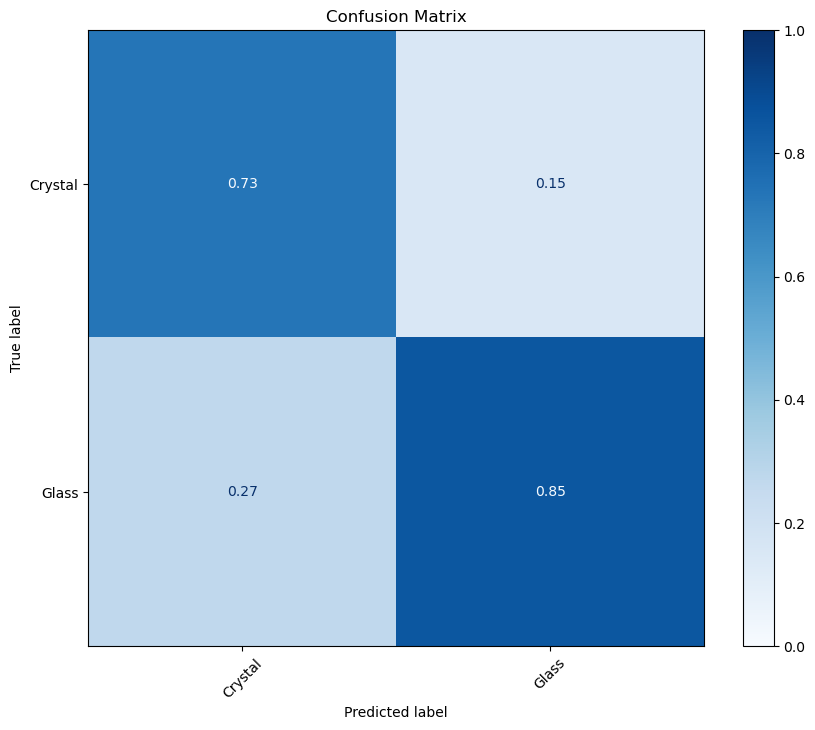

In [22]:
#RF = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)
RF = RandomForestClassifier(**all_hyperparams)

RF.fit(X_train_feateng_gs, y_train_feateng_gs)

y_pred_feateng_gs = RF.predict(X_test_feateng_gs)
y_pred_proba_feateng_gs = RF.predict_proba(X_test_feateng_gs)

classes_label_binary = ["Crystal", "Glass"]

evaluate_model(RF, X_test_feateng_gs, y_test_feateng_gs, labels_list=le.classes_, cm_normalize="pred")

In [23]:
# import numpy as np
# import shap
# from joblib import Parallel, delayed
# from tqdm import tqdm 

# n_jobs = 14 
# feat_names = df_feateng_gs[FEATURES].columns.to_list()
# explainer = shap.Explainer(RF, feature_names=feat_names, output_names=classes_label_binary, seed=RANDOM_SEED)

# # Split X_train into chunks (if one chunk finishes early, the core immediately picks up the next one).
# n_chunks = n_jobs * 20
# chunks = np.array_split(X_train_feateng_gs, n_chunks) 

# print(f"Splitting data into {n_chunks} chunks to run on {n_jobs} cores...")

# # Helper function
# def get_explanation(chunk):
#     # check_additivity=False prevents common numerical precision errors 
#     # that can occur when parallelizing Random Forest calculations
#     return explainer(chunk, check_additivity=False) 

# # Run in parallel with TQDM
# print("Calculating SHAP values...")

# explanations_list = Parallel(n_jobs=n_jobs)(
#     delayed(get_explanation)(chunk) for chunk in tqdm(chunks, desc="Progress")
# )

# # Concatenate results
# print("Concatenating results...")
# shap_values_all = np.concatenate([e.values for e in explanations_list], axis=0)
# base_values_all = np.concatenate([e.base_values for e in explanations_list], axis=0)
# data_all = np.concatenate([e.data for e in explanations_list], axis=0)

# # Reconstruct the final Explanation object
# explanation = shap.Explanation(
#     values=shap_values_all,
#     base_values=base_values_all,
#     data=data_all,
#     feature_names=feat_names,
#     output_names=classes_label_binary
# )

# print("Done! Shape:", explanation.values.shape)

# # Save the explanation object to a file
# joblib.dump(explanation, '../data/support/explanation_shap/explanation_shap_FEATENG_GS.joblib')
# print("Explanation object saved successfully!")

## Curve Validation

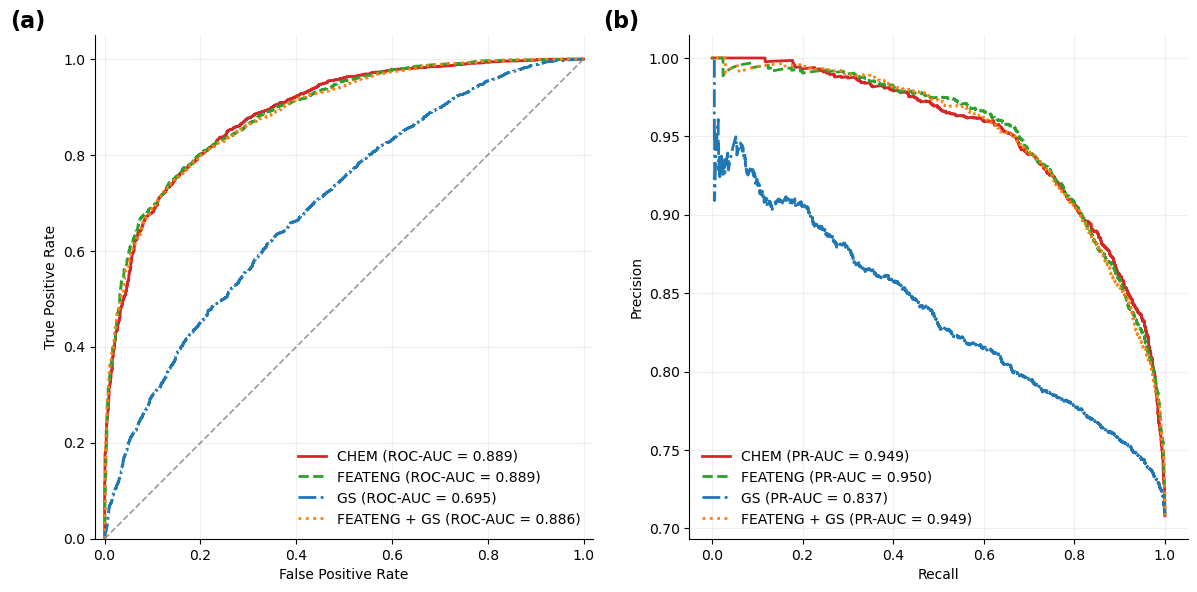

In [24]:
y_test = y_test_gs  # Same test set for all models

# Data Dictionary
models_data = {
    'CHEM': y_pred_proba_chem,
    'FEATENG': y_pred_proba_feateng,
    'GS': y_pred_proba_gs,
    'FEATENG + GS': y_pred_proba_feateng_gs

}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

colors = ['#d62728', '#2ca02c', '#1f77b4', '#ff7f0e']
linestyles = ['-', '--', '-.', ':']
#linestyles = ['-', '-', '-', '-']


# Plot 1: ROC Curve
for (name, y_proba), color, ls in zip(models_data.items(), colors, linestyles):
    
    if y_proba.ndim == 2 and y_proba.shape[1] == 2:
        y_score = y_proba[:, 1]
    else:
        y_score = y_proba.ravel()
        
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, linestyle=ls, lw=2,
             label=f'{name} (ROC-AUC = {roc_auc:.3f})')

# Random guess line
ax1.plot([0, 1], [0, 1], color='gray', lw=1.2, linestyle='--', alpha=0.8)

ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right", frameon=False)
ax1.grid(alpha=0.2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax1.text(-0.1, 1.05, '(a)', transform=ax1.transAxes, 
         fontsize=16, fontweight='bold', va='top', ha='right')

# Plot 2: Precision-Recall Curve 
for (name, y_proba), color, ls in zip(models_data.items(), colors, linestyles):
    
    if y_proba.ndim == 2 and y_proba.shape[1] == 2:
        y_score = y_proba[:, 1]
    else:
        y_score = y_proba.ravel()

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    ax2.plot(recall, precision, color=color, linestyle=ls, lw=2,
             label=f'{name} (PR-AUC = {ap:.3f})')

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc="lower left", frameon=False)
ax2.grid(alpha=0.2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax2.text(-0.1, 1.05, '(b)', transform=ax2.transAxes, 
         fontsize=16, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison_curves.png', dpi=300, bbox_inches='tight')
plt.show()

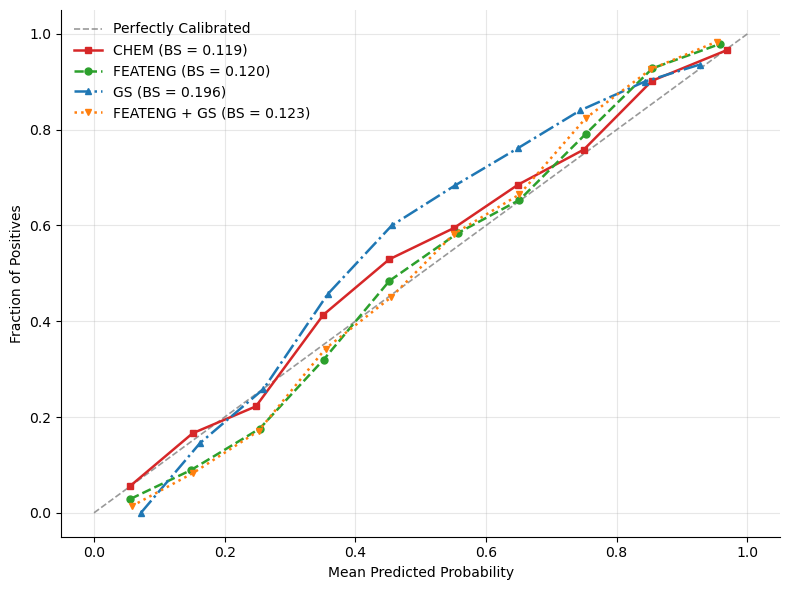

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

# Perfect calibration line
#ax.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated", linewidth=1.5)
ax.plot([0, 1], [0, 1], color='gray', label="Perfectly Calibrated", lw=1.2, linestyle='--', alpha=0.8)

# Colors and markers
colors = ['#d62728', '#2ca02c', '#1f77b4', '#ff7f0e']
markers = ['s', 'o', '^', 'v']
linestyles = ['-', '--', '-.', ':']
#linestyles = ['-', '-', '-', '-']

# Plot Calibration Curves
for (name, y_proba), color, marker, ls in zip(models_data.items(), colors, markers, linestyles):
    
    if y_proba.ndim == 2 and y_proba.shape[1] == 2:
        y_score = y_proba[:, 1]
    else:
        y_score = y_proba.ravel()

    # Calculate calibration curve
    # n_bins=10 means we check deciles (0-10%, 10-20%, etc.)
    prob_true, prob_pred = calibration_curve(y_test, y_score, n_bins=10)
    
    # Calculate Brier Score using the 1D score (Lower is better)
    bs = brier_score_loss(y_test, y_score)
    
    ax.plot(prob_pred, prob_true, marker=marker, markersize=5, 
            color=color, linewidth=1.8, linestyle=ls,
            label=f'{name} (BS = {bs:.3f})')

ax.set_ylabel('Fraction of Positives')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylim([-0.05, 1.05])
ax.set_xlim([-0.05, 1.05])

ax.legend(loc="upper left", frameon=False)
ax.grid(alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/calibration_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## Classification Metrics Comparison

In [29]:
def extract_metrics_from_notebook(file_path):
    """Reads the .ipynb file and extracts evaluation metrics from the outputs."""
    with open(file_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    metrics_blocks = []
    # Loop through all cells looking for text outputs containing the metrics
    for cell in nb.get('cells', []):
        if cell.get('cell_type') == 'code':
            for out in cell.get('outputs', []):
                if out.get('output_type') == 'stream':
                    text = "".join(out.get('text', []))
                    if '===== Evaluation Metrics =====' in text:
                        metrics_blocks.append(text)

    # Dictionary with the target metrics and their respective Regex patterns
    patterns = {
        r'Accuracy (\uparrow)': r'Accuracy:\s+([0-9.]+)',
        r'Weighted Accuracy (\uparrow)': r'Balanced Accuracy:\s+([0-9.]+)',
        r'ROC-AUC (\uparrow)': r'ROC AUC:\s+([0-9.]+)',
        r'PR-AUC (\uparrow)': r'PR AUC \(class 1\):\s+([0-9.]+)',
        r'Macro PR-AUC (\uparrow)': r'PR AUC \(macro\):\s+([0-9.]+)',
        r'F1-Score (\uparrow)': r'F1-Score \(class 1\):\s+([0-9.]+)',
        r'Macro F1-Score (\uparrow)': r'F1-Score \(macro\):\s+([0-9.]+)',
        r'Brier Score (\downarrow)': r'Brier Score Loss:\s+([0-9.]+)',
        r'Log Loss (\downarrow)': r'Log Loss:\s+([0-9.]+)'
    }

    model_names = ['CHEM', 'FEATENG', 'GS', 'FEATENG+GS']
    data = {'Dataset': list(patterns.keys())}
    for model in model_names:
        data[model] = []

    # Extract values block by block
    for i, block in enumerate(metrics_blocks):
        if i >= len(model_names): 
            break
            
        model = model_names[i]
        for metric, pattern in patterns.items():
            match = re.search(pattern, block)
            val = round(float(match.group(1)), 3) if match else np.nan
            data[model].append(val)

    return data

def generate_and_save_outputs(data, path_txt = '../data/support/analysis_table/model_metrics_comparison.txt', path_xlsx = '../data/support/analysis_table/model_metrics_comparison.xlsx'):
    """Transforms the data into Markdown, saves as TXT, and exports to XLSX."""
    df = pd.DataFrame(data)
    
    # Convert to object type to allow string assignments (*0.824*)
    formatted_df = df.astype(object).copy()

    # Logic to find the best value (maximum or minimum)
    for i, row in df.iterrows():
        metric = row['Dataset']
        values = row[1:].astype(float).values
        
        # If the metric has a down arrow (\downarrow), the LOWEST value is best
        if 'downarrow' in metric:
            best_val = np.nanmin(values)
        else:
            # Otherwise, the HIGHEST value is best
            best_val = np.nanmax(values)
            
        # Apply asterisks (*) to the best values and format with 3 decimal places
        for col in df.columns[1:]:
            val = row[col]
            if val == best_val:
                formatted_df.at[i, col] = f"*{val:.3f}*"
            else:
                formatted_df.at[i, col] = f"{val:.3f}"

    # Generate Markdown String
    markdown_table = "| Dataset                      |   CHEM | FEATENG |     GS | FEATENG+GS |\n"
    markdown_table += "| <l>                          |    <r> |     <r> |    <r> |        <r> |\n"
    markdown_table += "|------------------------------+--------+---------+--------+------------|\n"
    for i, row in formatted_df.iterrows():
        col1 = f"| {row['Dataset']:<28} "
        col2 = f"| {row['CHEM']:>6} "
        col3 = f"| {row['FEATENG']:>7} "
        col4 = f"| {row['GS']:>6} "
        col5 = f"| {row['FEATENG+GS']:>10} |\n"
        markdown_table += col1 + col2 + col3 + col4 + col5
    markdown_table += "|------------------------------+--------+---------+--------+------------|"

    # Save as TXT file
    with open(path_txt, 'w', encoding='utf-8') as f:
        f.write(markdown_table)
    print("-> Successfully saved", path_txt)

    # Save as XLSX (Excel) file
    # Requires the 'openpyxl' library installed (pip install openpyxl)
    with pd.ExcelWriter(path_xlsx) as writer:
        df.to_excel(writer, sheet_name='Raw Numbers', index=False)
        formatted_df.to_excel(writer, sheet_name='Formatted with Asterisks', index=False)
    print("-> Successfully saved", path_xlsx)

    return markdown_table

# --- Main Execution ---
file_path = '2_machine_learning_analysis.ipynb'

# Extract data
extracted_data = extract_metrics_from_notebook(file_path)

# Generate strings and save output files
final_table = generate_and_save_outputs(extracted_data)

# Print out the final table
print("\n" + final_table)

-> Successfully saved ../data/support/analysis_table/model_metrics_comparison.txt
-> Successfully saved ../data/support/analysis_table/model_metrics_comparison.xlsx

| Dataset                      |   CHEM | FEATENG |     GS | FEATENG+GS |
| <l>                          |    <r> |     <r> |    <r> |        <r> |
|------------------------------+--------+---------+--------+------------|
| Accuracy (\uparrow)          | *0.826* |   0.824 |  0.704 |      0.822 |
| Weighted Accuracy (\uparrow) | *0.779* |   0.766 |  0.621 |      0.761 |
| ROC-AUC (\uparrow)           | *0.889* | *0.889* |  0.695 |      0.886 |
| PR-AUC (\uparrow)            |  0.949 | *0.950* |  0.837 |      0.949 |
| Macro PR-AUC (\uparrow)      |  0.865 | *0.866* |  0.673 |      0.864 |
| F1-Score (\uparrow)          | *0.879* | *0.879* |  0.797 |      0.878 |
| Macro F1-Score (\uparrow)    | *0.785* |   0.777 |  0.625 |      0.773 |
| Brier Score (\downarrow)     | *0.119* |   0.120 |  0.196 |      0.123 |
| Log Loss (\d

## Save Parameters Model

In [27]:
import os
import json
import ast

def extract_and_save_hyperparameters(file_path, output_dir="../data/support/model_parameters"):
    """Extracts the hyperparameters for each model in the notebook and saves them in a directory."""

    os.makedirs(output_dir, exist_ok=True)
    
    with open(file_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    param_blocks = []
    
    # Iterate through the notebook cells looking for configurations
    for cell in nb.get('cells', []):
        if cell.get('cell_type') == 'code':
            for out in cell.get('outputs', []):
                if out.get('output_type') == 'stream':
                    text = "".join(out.get('text', []))
                    if 'Listing all parameters:' in text:
                        # Extract only the dictionary part (after "Listing all parameters:")
                        dict_str = text.split('Listing all parameters:\n')[1].strip()
                        param_blocks.append(dict_str)

    # Model names in the order they appear
    model_names = ['CHEM', 'FEATENG', 'GS', 'FEATENG_GS']
    saved_files = []

    # Convert strings to dictionaries and save
    for i, dict_str in enumerate(param_blocks):
        if i >= len(model_names):
            break
            
        model_name = model_names[i]
        
        try:
            # Convert the text string to an actual Python dictionary
            params_dict = ast.literal_eval(dict_str)
            
            # File path (e.g., support/CHEM_params.json)
            file_name = f"{model_name}_params.json"
            save_path = os.path.join(output_dir, file_name)
            
            # Save the dictionary as a properly formatted JSON file
            with open(save_path, 'w', encoding='utf-8') as f:
                json.dump(params_dict, f, indent=4)
                
            saved_files.append(save_path)
            print(f"-> Successfully saved: {save_path}")
            
        except Exception as e:
            print(f"Error processing parameters for model {model_name}: {e}")

    return saved_files

# --- Execution ---
file_path = '2_machine_learning_analysis.ipynb'
extract_and_save_hyperparameters(file_path)

-> Successfully saved: ../data/support/model_parameters/CHEM_params.json
-> Successfully saved: ../data/support/model_parameters/FEATENG_params.json
-> Successfully saved: ../data/support/model_parameters/GS_params.json
-> Successfully saved: ../data/support/model_parameters/FEATENG_GS_params.json


['../data/support/model_parameters/CHEM_params.json',
 '../data/support/model_parameters/FEATENG_params.json',
 '../data/support/model_parameters/GS_params.json',
 '../data/support/model_parameters/FEATENG_GS_params.json']

In [28]:
import json
import ast
import pandas as pd
import numpy as np

def extract_hyperparameters_from_notebook(file_path):
    """Reads the .ipynb file and extracts hyperparameter dictionaries from the outputs."""
    with open(file_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    param_blocks = []
    # Loop through all cells looking for text outputs containing the hyperparameters
    for cell in nb.get('cells', []):
        if cell.get('cell_type') == 'code':
            for out in cell.get('outputs', []):
                if out.get('output_type') == 'stream':
                    text = "".join(out.get('text', []))
                    if 'Listing all parameters:' in text:
                        # Extract the dictionary string
                        dict_str = text.split('Listing all parameters:\n')[1].strip()
                        param_blocks.append(dict_str)

    model_names = ['CHEM', 'FEATENG', 'GS', 'FEATENG+GS']
    data = {model: {} for model in model_names}

    # Extract values block by block
    for i, block in enumerate(param_blocks):
        if i >= len(model_names): 
            break
            
        model = model_names[i]
        try:
            # Safely evaluate the string as a Python dictionary
            data[model] = ast.literal_eval(block)
        except Exception as e:
            print(f"Error parsing hyperparameters for {model}: {e}")

    return data

def format_hyperparam_value(v):
    """Formats the values to match the table standard (None, strings, integers, or \\num notation)."""
    if v is None:
        return "None"
    elif isinstance(v, bool):
        return str(v)
    elif isinstance(v, str):
        return v
    elif isinstance(v, int):
        return str(v)
    elif isinstance(v, float):
        if v == 0.0:
            return "0"
        else:
            # Format floats to LaTeX \num{X.XXe-Y}
            sci_str = f"{v:.2e}"
            base, exp = sci_str.split('e')
            exp = int(exp) # Convert to int to remove leading zeros (e.g., e-05 -> e-5)
            return rf"\num{{{base}e{exp}}}"
    return str(v)

def generate_and_save_hyperparams(data, path_txt='../data/support/analysis_table/model_hyperparameters_comparison.txt', path_xlsx='../data/support/analysis_table/model_hyperparameters_comparison.xlsx'):
    """Transforms the hyperparameter data into Markdown, saves as TXT, and exports to XLSX."""
    
    # Define the search space mappings and order
    search_spaces = {
        'n_estimators': r'{10, 11, ..., 1000}',
        'criterion': r'{gini, entropy, log_loss}',
        'min_samples_split': r'{2, 3, ..., 20}',
        'min_samples_leaf': r'{1, 2, ..., 20}',
        'max_depth': r'{None} $\cup$ {1, 2, ..., 100}',
        'max_features': r'{sqrt, log2, None} $\cup$ [\num{e-5}, 1]',
        'max_leaf_nodes': r'{None} $\cup$ {10, 11, ..., 1000}',
        'min_impurity_decrease': r'{0} $\cup$ [\num{e-5}, 1]',
        'class_weight': r'{None, balanced, balanced_subsample}',
        'ccp_alpha': r'{0} $\cup$ [\num{e-5}, 1]',
        'max_samples': r'{None} $\cup$ [\num{e-4}, 1]'
    }

    model_names = ['CHEM', 'FEATENG', 'GS', 'FEATENG+GS']
    
    # Build dictionaries for DataFrames
    raw_dict = {'Hyperparameter': list(search_spaces.keys()), 'Search space': list(search_spaces.values())}
    fmt_dict = {'Hyperparameter': list(search_spaces.keys()), 'Search space': list(search_spaces.values())}
    
    for model in model_names:
        raw_dict[model] = []
        fmt_dict[model] = []
        for hp in search_spaces.keys():
            val = data[model].get(hp, None)
            raw_dict[model].append(val)
            fmt_dict[model].append(format_hyperparam_value(val))

    df_raw = pd.DataFrame(raw_dict)
    df_fmt = pd.DataFrame(fmt_dict)

    # Generate Markdown String
    markdown_table = "| Hyperparameter        | Search space                             |               CHEM |  FEATENG |                 GS |    FEATENG+GS |\n"
    markdown_table += "| <l>                   | <l>                                      |                <r> |      <r> |                <r> |           <r> |\n"
    markdown_table += "|-----------------------+------------------------------------------+--------------------+----------+--------------------+---------------|\n"
    
    for i, row in df_fmt.iterrows():
        hp = row['Hyperparameter']
        space = row['Search space']
        chem = row['CHEM']
        feateng = row['FEATENG']
        gs = row['GS']
        feateng_gs = row['FEATENG+GS']
        
        markdown_table += f"| {hp:<21} | {space:<40} | {chem:>18} | {feateng:>8} | {gs:>18} | {feateng_gs:>13} |\n"
        
    markdown_table += "|-----------------------+------------------------------------------+--------------------+----------+--------------------+---------------|"

    # Save as TXT file
    with open(path_txt, 'w', encoding='utf-8') as f:
        f.write(markdown_table)
    print("-> Successfully saved", path_txt)

    # Save as XLSX (Excel) file
    with pd.ExcelWriter(path_xlsx) as writer:
        df_raw.to_excel(writer, sheet_name='Raw Numbers', index=False)
        df_fmt.to_excel(writer, sheet_name='Formatted Table', index=False)
    print("-> Successfully saved", path_xlsx)

    return markdown_table

# --- Main Execution ---
file_path = '2_machine_learning_analysis.ipynb'

# Extract data
extracted_hyperparams = extract_hyperparameters_from_notebook(file_path)

# Generate strings and save output files
final_table_hp = generate_and_save_hyperparams(extracted_hyperparams)

# Print out the final table
print("\n" + final_table_hp)

-> Successfully saved ../data/support/analysis_table/model_hyperparameters_comparison.txt
-> Successfully saved ../data/support/analysis_table/model_hyperparameters_comparison.xlsx

| Hyperparameter        | Search space                             |               CHEM |  FEATENG |                 GS |    FEATENG+GS |
| <l>                   | <l>                                      |                <r> |      <r> |                <r> |           <r> |
|-----------------------+------------------------------------------+--------------------+----------+--------------------+---------------|
| n_estimators          | {10, 11, ..., 1000}                      |                722 |      719 |                419 |           384 |
| criterion             | {gini, entropy, log_loss}                |               gini | log_loss |           log_loss |      log_loss |
| min_samples_split     | {2, 3, ..., 20}                          |                  3 |        7 |                 15 |       